# AI212 Hatchery Regression: Repaired OLS vs Bayesian Analysis

This notebook is the cleaned-up implementation for the hatchery capstone. It fixes the earlier weak points by:

- using a stricter cleaning pipeline
- selecting **five conceptual predictors** with better sample coverage
- excluding variables that were constant, duplicated, or strongly collinear
- modeling `AGE` with a cubic basis after EDA showed nonlinearity
- comparing OLS with Bayesian regression under weak and informative priors
- evaluating model complexity with 5-fold CV, 0.632 bootstrap, AIC, and WAIC

**Section 0** below defines all helper functions. Sections 1–7 call those functions and display results.

## 0. Implementation

The cells below define every function used in this notebook, organized into eight groups:

| Cell | Contents |
|------|----------|
| 0.1 | Imports, constants, and utility functions |
| 0.2 | Data path resolution and `load_and_clean_hatch_model` |
| 0.3 | `build_modeling_frame` and `summarize_full_candidate_screen` |
| 0.4 | `age_curve_diagnostics` and `plot_age_curve_diagnostics` |
| 0.5 | `design_matrix_for_complexity` |
| 0.6 | `fit_ols_model`, VIF, residual diagnostics |
| 0.7 | Bayesian NIG fitting, WAIC, posterior utilities |
| 0.8 | Cross-validation, bootstrap, and `run_complexity_analysis` |
| 0.9 | Complexity plots, `fit_full_models`, and `save_summary_tables` |

In [1]:
from __future__ import annotations

import os
import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

from IPython.display import display, Image

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from scipy.special import logsumexp
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

# ── Constants ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 212
TARGET_COUNT_COL = "CLEAN_CHICKS"
DENOM_COL = "EGGSET"
TARGET_RATIO_COL = "CLEAN_CHICKS_RATIO"
TARGET_PCT_COL = "CLEAN_CHICKS_PCT"
SHEET_NAME = "DB"
USECOLS = "B:P,AE"
CONCEPTUAL_PREDICTORS = ["AGE", "S.P.", "LINE", "FARM_SOURCE", "STRAIN"]
COMPLEXITY_LABELS = {
    1: "AGE (cubic basis)",
    2: "AGE + S.P.",
    3: "AGE + S.P. + LINE",
    4: "AGE + S.P. + LINE + FARM_SOURCE",
    5: "AGE + S.P. + LINE + FARM_SOURCE + STRAIN",
}


@dataclass
class DesignMetadata:
    age_center: float
    line_categories: list
    farm_source_categories: list
    strain_categories: list


# ── Utilities ──────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred) -> float:
    return math.sqrt(mean_squared_error(y_true, y_pred))

def normalize_header(col: str) -> str:
    return " ".join(str(col).replace("\n", " ").strip().split())

def canonical_key(col: str) -> str:
    return "".join(ch for ch in str(col).upper() if ch.isalnum())

In [2]:
# ── 0.2  Data path resolution and load_and_clean_hatch_model ──────────────────

def resolve_data_path() -> Path:
    search_bases = [Path.cwd(), *Path.cwd().parents]
    candidates = []
    for base in search_bases:
        candidates.extend([
            base / "Bayesian_non_Bayesian" / "Hatch_Model.xlsx",
            base / "Hatch_Model.xlsx",
        ])
    candidates.append(Path(
        "/Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/Hatch_Model.xlsx"))
    return next((p for p in candidates if p.exists()), candidates[0])


DATA_PATH = resolve_data_path()
OUTPUT_DIR = DATA_PATH.parent / "hatch_outputs_refined"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)


def load_and_clean_hatch_model(max_rows="max", row_selection_mode="latest"):
    nrows_arg = None if str(max_rows).lower() == "max" else int(max_rows)
    raw_df = pd.read_excel(DATA_PATH, sheet_name="DB", usecols="B:P,AE",
                            nrows=nrows_arg, engine="openpyxl")
    raw_df.columns = [normalize_header(c) for c in raw_df.columns]

    rename_via_canonical = {
        "WEEKNO": "WEEK_NO", "HATCHDATE": "HATCH_DATE", "DATESET": "DATE_SET",
        "FARMSOURCE": "FARM_SOURCE", "PRODNDATE": "PRODN_DATE",
        "GROUP": "GRP", "GRP": "GRP", "CLEANCHICKS": "CLEAN_CHICKS",
        "B": "B", "B#": "B", "H": "H", "H#": "H",
    }
    canon_to_actual = {canonical_key(c): c for c in raw_df.columns}
    rename_map = {canon_to_actual[k]: v for k, v in rename_via_canonical.items()
                  if k in canon_to_actual}
    df = raw_df.rename(columns=rename_map).copy()

    required_cols = ["HY", "LOCATION", "WEEK_NO", "HATCH_DATE", "DATE_SET", "FARM_SOURCE",
                     "LINE", "B", "H", "STRAIN", "PRODN_DATE", "AGE", "GRP", "S.P.",
                     DENOM_COL, TARGET_COUNT_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    summary_mask = df["HY"].astype(str).str.upper().str.contains("GRAND TOTAL", na=False)
    cleaning_counts = {"raw_selected_rows": int(len(raw_df)),
                       "summary_rows_removed": int(summary_mask.sum())}
    df = df.loc[~summary_mask].copy()
    cleaning_counts["after_summary_filter"] = int(len(df))

    for col in ["HATCH_DATE", "DATE_SET", "PRODN_DATE"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    for col in ["AGE", "GRP", "S.P.", "B", "H", DENOM_COL, TARGET_COUNT_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    core_mask = (df["HATCH_DATE"].notna() & df["DATE_SET"].notna() & df["PRODN_DATE"].notna()
                 & df[DENOM_COL].notna() & df[TARGET_COUNT_COL].notna() & df[DENOM_COL].gt(0)
                 & df["AGE"].notna() & df["S.P."].notna()
                 & df["LINE"].notna() & df["FARM_SOURCE"].notna() & df["STRAIN"].notna())
    df = df.loc[core_mask].copy()
    cleaning_counts["after_core_filter"] = int(len(df))

    before_dedup = len(df)
    df = df.drop_duplicates().copy()
    cleaning_counts["duplicates_removed"] = int(before_dedup - len(df))
    cleaning_counts["after_deduplication"] = int(len(df))

    df[TARGET_RATIO_COL] = df[TARGET_COUNT_COL] / df[DENOM_COL]
    df[TARGET_PCT_COL] = df[TARGET_RATIO_COL] * 100
    target_mask = (df[TARGET_RATIO_COL].notna() & np.isfinite(df[TARGET_RATIO_COL])
                   & df[TARGET_RATIO_COL].between(0, 1))
    df = df.loc[target_mask].copy()
    cleaning_counts["after_target_filter"] = int(len(df))

    df["INCUBATION_DAYS"] = (df["HATCH_DATE"] - df["DATE_SET"]).dt.days
    df["STORAGE_DAYS_CALC"] = (df["DATE_SET"] - df["PRODN_DATE"]).dt.days
    df["WEEK_NO_NUM"] = df["WEEK_NO"].astype(str).str.extract(r"(\d+)", expand=False).astype(float)
    df = df.sort_values(["HATCH_DATE", "DATE_SET", "PRODN_DATE"],
                         na_position="last").reset_index(drop=True)

    if str(max_rows).lower() != "max":
        max_rows_int = int(max_rows)
        df = (df.tail(max_rows_int) if row_selection_mode == "latest"
              else df.head(max_rows_int)).reset_index(drop=True)

    assert not df.columns.duplicated().any()
    assert df[DENOM_COL].gt(0).all()
    assert df[TARGET_RATIO_COL].between(0, 1).all()
    return raw_df, df, pd.Series(cleaning_counts, name="rows")

Data path: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/Hatch_Model.xlsx
Output dir: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/hatch_outputs_refined


In [3]:
# ── 0.3  Modeling frame and predictor screening ───────────────────────────────

def build_modeling_frame(frame: pd.DataFrame):
    modeling_df = frame.copy()
    labels = [f"Q{i}" for i in range(1, 7)]
    modeling_df["AGE_BUCKET"] = pd.qcut(modeling_df["AGE"], q=6, labels=labels, duplicates="drop")
    modeling_df["AGE_CENTERED"] = modeling_df["AGE"] - float(modeling_df["AGE"].median())
    modeling_df["AGE_CENTERED_SQ"] = modeling_df["AGE_CENTERED"] ** 2
    modeling_df["AGE_CENTERED_CU"] = modeling_df["AGE_CENTERED"] ** 3
    for col in ["LINE", "FARM_SOURCE", "LOCATION", "STRAIN"]:
        modeling_df[col] = modeling_df[col].astype(str)
    strain_counts = modeling_df["STRAIN"].value_counts()
    rare_strains = strain_counts[strain_counts < 100].index
    modeling_df["STRAIN"] = modeling_df["STRAIN"].where(~modeling_df["STRAIN"].isin(rare_strains), "OTHER")
    screening = {
        "selected_conceptual_predictors": CONCEPTUAL_PREDICTORS,
        "excluded_predictors": {
            "GRP": "corr(AGE, GRP) is extremely high — causes multicollinearity.",
            "INCUBATION_DAYS": "Constant at 21 days in the cleaned data.",
            "STORAGE_DAYS_CALC": "Duplicates S.P. exactly after cleaning.",
            "H": "Missing for most rows — would shrink the sample too aggressively.",
            "Rare STRAIN levels": "Collapsed into OTHER to avoid unstable dummy-coefficient inference.",
        },
    }
    return modeling_df, screening


def summarize_full_candidate_screen(modeling_df: pd.DataFrame) -> pd.DataFrame:
    candidate_cols = ["AGE", "GRP", "S.P.", "B", "INCUBATION_DAYS", "STORAGE_DAYS_CALC"]
    corr = modeling_df[candidate_cols + [TARGET_RATIO_COL]].corr(numeric_only=True)
    rows = []
    for col in candidate_cols:
        rows.append({
            "candidate": col,
            "corr_with_target": float(corr.loc[col, TARGET_RATIO_COL]),
            "corr_with_age": float(corr.loc[col, "AGE"]) if col != "AGE" else 1.0,
            "n_unique": int(modeling_df[col].nunique(dropna=True)),
        })
    return pd.DataFrame(rows).sort_values("candidate").reset_index(drop=True)

In [4]:
# ── 0.4  EDA and AGE-curve diagnostics ────────────────────────────────────────

def age_curve_diagnostics(modeling_df: pd.DataFrame):
    age_pattern = (modeling_df[["AGE", TARGET_RATIO_COL, DENOM_COL, "AGE_BUCKET"]]
                   .dropna(subset=["AGE", TARGET_RATIO_COL, DENOM_COL])
                   .loc[lambda df: df[DENOM_COL] > 0].copy())

    def _weighted_age_summary(group):
        weights = group[DENOM_COL].astype(float)
        actual = group[TARGET_RATIO_COL].astype(float)
        return pd.Series({
            "rows": int(len(group)), "eggset": float(weights.sum()),
            "weighted_mean_ratio": float(np.average(actual, weights=weights)),
            "mean_ratio": float(actual.mean()), "ratio_std": float(actual.std()),
            "ratio_q10": float(actual.quantile(0.10)),
            "ratio_median": float(actual.median()),
            "ratio_q90": float(actual.quantile(0.90)),
            "age_midpoint": float(group["AGE"].median()),
        })

    age_curve_summary = (age_pattern.groupby("AGE_BUCKET", dropna=False, observed=True)
                         .apply(_weighted_age_summary).reset_index())

    age_center_value = float(modeling_df["AGE"].median())
    age_centered = age_pattern["AGE"].astype(float) - age_center_value
    y_age = age_pattern[TARGET_RATIO_COL].astype(float)
    weights = age_pattern[DENOM_COL].astype(float).clip(lower=1.0)
    sqrt_weights = np.sqrt(weights)
    age_poly_rows = []
    for degree in [1, 2, 3]:
        coeff = np.polyfit(age_centered, y_age, deg=degree, w=sqrt_weights)
        pred = np.clip(np.polyval(coeff, age_centered), 0, 1)
        residual = y_age - pred
        age_poly_rows.append({
            "age_only_model": f"degree_{degree}",
            "age_center": age_center_value,
            "weighted_ratio_mae": float(np.average(np.abs(residual), weights=weights)),
            "ratio_rmse": float(np.sqrt(np.mean(residual**2))),
            "residual_variance": float(np.var(residual)),
        })
    return age_curve_summary, pd.DataFrame(age_poly_rows)


def plot_age_curve_diagnostics(modeling_df: pd.DataFrame, age_curve_summary: pd.DataFrame,
                                output_dir: Path) -> None:
    age_pattern = (modeling_df[["AGE", TARGET_RATIO_COL, DENOM_COL, "AGE_BUCKET"]]
                   .dropna(subset=["AGE", TARGET_RATIO_COL, DENOM_COL])
                   .loc[lambda df: df[DENOM_COL] > 0].copy())
    age_center_value = float(modeling_df["AGE"].median())
    age_centered = age_pattern["AGE"].astype(float) - age_center_value
    y_age = age_pattern[TARGET_RATIO_COL].astype(float)
    weights = age_pattern[DENOM_COL].astype(float).clip(lower=1.0)
    sqrt_weights = np.sqrt(weights)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_sample = age_pattern.sample(n=min(len(age_pattern), 8000), random_state=RANDOM_STATE)
    axes[0].scatter(plot_sample["AGE"], plot_sample[TARGET_RATIO_COL], alpha=0.18, s=10, label="Batches")
    grid_age = np.linspace(age_pattern["AGE"].min(), age_pattern["AGE"].max(), 200)
    grid_centered = grid_age - age_center_value
    for degree, style in [(1, "--"), (2, "-"), (3, ":")]:
        coeff = np.polyfit(age_centered, y_age, deg=degree, w=sqrt_weights)
        axes[0].plot(grid_age, np.clip(np.polyval(coeff, grid_centered), 0, 1),
                     style, linewidth=2, label=f"Weighted degree {degree}")
    valid = age_curve_summary.dropna(subset=["age_midpoint", "weighted_mean_ratio"]).sort_values("age_midpoint")
    axes[0].plot(valid["age_midpoint"], valid["weighted_mean_ratio"],
                 color="black", marker="o", linewidth=2, label="Weighted bucket mean")
    axes[0].set_title("Clean-chicks ratio is nonlinear in AGE")
    axes[0].set_xlabel("AGE"); axes[0].set_ylabel(TARGET_RATIO_COL)
    axes[0].set_ylim(-0.02, 1.02); axes[0].legend(); axes[0].grid(True, alpha=0.25)
    axes[1].plot(valid["age_midpoint"], valid["ratio_std"], marker="o", color="tab:red")
    axes[1].set_title("Observed spread changes by AGE bucket")
    axes[1].set_xlabel("AGE bucket median"); axes[1].set_ylabel("Std. dev. of clean-chicks ratio")
    axes[1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_dir / "age_curve_diagnostic.png", dpi=150)
    plt.close()

In [5]:
# ── 0.5  Design matrix by complexity level ────────────────────────────────────

def initial_metadata(frame: pd.DataFrame) -> DesignMetadata:
    return DesignMetadata(
        age_center=float(frame["AGE"].median()),
        line_categories=sorted(frame["LINE"].astype(str).dropna().unique().tolist()),
        farm_source_categories=sorted(frame["FARM_SOURCE"].astype(str).dropna().unique().tolist()),
        strain_categories=sorted(frame["STRAIN"].astype(str).dropna().unique().tolist()),
    )


def design_matrix_for_complexity(frame: pd.DataFrame, k: int, metadata: DesignMetadata = None):
    if metadata is None:
        metadata = initial_metadata(frame)
    out = pd.DataFrame(index=frame.index)
    age_centered = frame["AGE"].astype(float) - metadata.age_center
    out["AGE_CENTERED"] = age_centered
    out["AGE_CENTERED_SQ"] = age_centered ** 2
    out["AGE_CENTERED_CU"] = age_centered ** 3
    if k >= 2:
        out["S.P."] = frame["S.P."].astype(float)
    if k >= 3:
        line_cat = pd.Categorical(frame["LINE"].astype(str), categories=metadata.line_categories)
        line_dummies = pd.get_dummies(line_cat, prefix="LINE", drop_first=True)
        line_dummies.index = frame.index
        out = pd.concat([out, line_dummies.astype(float)], axis=1)
    if k >= 4:
        farm_cat = pd.Categorical(frame["FARM_SOURCE"].astype(str),
                                   categories=metadata.farm_source_categories)
        farm_dummies = pd.get_dummies(farm_cat, prefix="FARM_SOURCE", drop_first=True)
        farm_dummies.index = frame.index
        out = pd.concat([out, farm_dummies.astype(float)], axis=1)
    if k >= 5:
        strain_cat = pd.Categorical(frame["STRAIN"].astype(str),
                                     categories=metadata.strain_categories)
        strain_dummies = pd.get_dummies(strain_cat, prefix="STRAIN", drop_first=True)
        strain_dummies.index = frame.index
        out = pd.concat([out, strain_dummies.astype(float)], axis=1)
    out.columns = [str(c) for c in out.columns]
    return out, metadata

In [6]:
# ── 0.6  OLS fitting, VIF, residual diagnostics ───────────────────────────────

def fit_ols_model(X: pd.DataFrame, y):
    X_sm = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X_sm).fit()
    robust = model.get_robustcov_results(cov_type="HC3")
    robust_ci = robust.conf_int()
    robust_table = pd.DataFrame({
        "term": model.params.index,
        "estimate": robust.params,
        "robust_se_hc3": robust.bse,
        "t_value_hc3": robust.tvalues,
        "p_value_hc3": robust.pvalues,
        "ci_95_low_hc3": robust_ci[:, 0],
        "ci_95_high_hc3": robust_ci[:, 1],
    })
    return model, robust_table


def compute_vif_table(modeling_df: pd.DataFrame, age_center: float) -> pd.DataFrame:
    vif_frame = modeling_df[["AGE", "S.P."]].dropna().copy()
    vif_frame["AGE_RAW_SQ"] = vif_frame["AGE"] ** 2
    vif_frame["AGE_RAW_CU"] = vif_frame["AGE"] ** 3
    raw = sm.add_constant(vif_frame[["AGE", "AGE_RAW_SQ", "AGE_RAW_CU", "S.P."]], has_constant="add")
    centered = vif_frame.copy()
    centered["AGE_CENTERED"] = centered["AGE"] - age_center
    centered["AGE_CENTERED_SQ"] = centered["AGE_CENTERED"] ** 2
    centered["AGE_CENTERED_CU"] = centered["AGE_CENTERED"] ** 3
    centered = sm.add_constant(
        centered[["AGE_CENTERED", "AGE_CENTERED_SQ", "AGE_CENTERED_CU", "S.P."]], has_constant="add")
    rows = []
    for label, frame in [("raw_age_polynomial", raw), ("centered_age_polynomial", centered)]:
        for idx, col in enumerate(frame.columns):
            if col == "const":
                continue
            rows.append({"design": label, "term": col,
                         "vif": float(variance_inflation_factor(frame.to_numpy(dtype=float), idx))})
    return pd.DataFrame(rows)


def summarize_residuals_by_age(modeling_df: pd.DataFrame, fitted: np.ndarray) -> pd.DataFrame:
    resid_df = modeling_df[["AGE_BUCKET", DENOM_COL]].copy()
    resid_df["residual"] = modeling_df[TARGET_RATIO_COL].to_numpy() - fitted
    return (resid_df.groupby("AGE_BUCKET", dropna=False, observed=True)
            .apply(lambda g: pd.Series({
                "rows": int(len(g)),
                "mean_residual": float(g["residual"].mean()),
                "residual_std": float(g["residual"].std()),
                "abs_residual_p90": float(np.percentile(np.abs(g["residual"]), 90)),
                "weighted_ratio_mae": float(np.average(np.abs(g["residual"]), weights=g[DENOM_COL])),
            })).reset_index())


def plot_residual_diagnostics(modeling_df: pd.DataFrame, fitted: np.ndarray, output_dir: Path) -> None:
    resid_df = modeling_df.copy()
    resid_df["ols_residual"] = modeling_df[TARGET_RATIO_COL].to_numpy() - fitted
    sample = resid_df.sample(n=min(len(resid_df), 6000), random_state=RANDOM_STATE).copy()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].scatter(sample["AGE"], sample["ols_residual"], alpha=0.20, s=10)
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title("OLS Cubic: Residuals vs AGE"); axes[0, 0].set_xlabel("AGE")
    axes[0, 0].set_ylabel("Residual"); axes[0, 0].grid(True, alpha=0.25)
    axes[0, 1].scatter(fitted[sample.index], sample["ols_residual"], alpha=0.20, s=10)
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].set_title("OLS Cubic: Residuals vs Fitted")
    axes[0, 1].set_xlabel("Fitted clean-chicks ratio"); axes[0, 1].set_ylabel("Residual")
    axes[0, 1].grid(True, alpha=0.25)
    axes[1, 0].hist(sample["ols_residual"], bins=40, alpha=0.85)
    axes[1, 0].set_title("OLS Cubic: Residual Histogram")
    axes[1, 0].set_xlabel("Residual"); axes[1, 0].set_ylabel("Rows"); axes[1, 0].grid(True, alpha=0.25)
    stats.probplot(sample["ols_residual"], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("OLS Cubic: Q-Q Plot"); axes[1, 1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_dir / "ols_cubic_residual_diagnostics.png", dpi=150)
    plt.close()

In [7]:
# ── 0.7  Bayesian Normal-Inverse-Gamma fitting ────────────────────────────────

def standardize_matrix(X: pd.DataFrame):
    means = X.mean(axis=0).to_numpy(dtype=float)
    scales = X.std(axis=0, ddof=0).to_numpy(dtype=float)
    scales = np.where(scales <= 1e-12, 1.0, scales)
    X_std = (X.to_numpy(dtype=float) - means) / scales
    return X_std, means, scales


def back_transform_beta_samples(beta_samples_std, means, scales, term_names):
    samples = np.asarray(beta_samples_std)
    out = np.empty_like(samples)
    out[:, 1:] = samples[:, 1:] / scales
    out[:, 0] = samples[:, 0] - np.sum(samples[:, 1:] * means / scales, axis=1)
    return pd.DataFrame(out, columns=["Intercept"] + term_names)


def summarize_samples(samples_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for term in samples_df.columns:
        values = samples_df[term].to_numpy(dtype=float)
        rows.append({"term": term,
                     "posterior_mean": float(np.mean(values)),
                     "credible_95_low": float(np.quantile(values, 0.025)),
                     "credible_95_high": float(np.quantile(values, 0.975))})
    return pd.DataFrame(rows)


def fit_bayesian_nig(X: pd.DataFrame, y,
                     prior_mean=None, prior_sd=1000.0,
                     a0: float = 0.001, b0: float = 0.001,
                     n_samples: int = 4000, random_state: int = RANDOM_STATE) -> dict:
    term_names = list(X.columns)
    X_std, means, scales = standardize_matrix(X)
    X_design = np.column_stack([np.ones(X_std.shape[0]), X_std])
    y_vec = np.asarray(y, dtype=float).reshape(-1, 1)
    n, p = X_design.shape

    m0 = np.zeros((p, 1)) if prior_mean is None else np.asarray(prior_mean, dtype=float).reshape(-1, 1)
    prior_sd_vec = np.broadcast_to(np.asarray(prior_sd, dtype=float), (p,))
    V0 = np.diag(prior_sd_vec**2)
    V0_inv = np.linalg.inv(V0)

    XtX = X_design.T @ X_design
    Xty = X_design.T @ y_vec
    precision_n = V0_inv + XtX
    Vn = np.linalg.inv(precision_n)
    mn = Vn @ (V0_inv @ m0 + Xty)
    an = a0 + n / 2
    residual_term = y_vec - X_design @ mn
    prior_shift = mn - m0
    bn = max(float((b0 + 0.5 * (residual_term.T @ residual_term
                                 + prior_shift.T @ V0_inv @ prior_shift)).item()), 1e-12)

    local_rng = np.random.default_rng(random_state)
    sigma2_samples = stats.invgamma(a=an, scale=bn).rvs(size=n_samples, random_state=local_rng)
    jitter = 1e-12
    for _ in range(8):
        try:
            chol = np.linalg.cholesky(Vn + jitter * np.eye(p)); break
        except np.linalg.LinAlgError:
            jitter *= 10
    else:
        eigvals, eigvecs = np.linalg.eigh(Vn)
        chol = eigvecs @ np.diag(np.sqrt(np.clip(eigvals, 1e-10, None)))

    z = local_rng.normal(size=(n_samples, p))
    beta_samples_std = mn.flatten() + (z @ chol.T) * np.sqrt(sigma2_samples)[:, None]
    beta_samples_original = back_transform_beta_samples(beta_samples_std, means, scales, term_names)
    original_table = summarize_samples(beta_samples_original)
    fitted = (X_design @ mn).flatten()
    train_rmse = rmse(y, fitted)

    df_t = 2 * an
    tcrit = stats.t.ppf(0.975, df=df_t)
    x_v_x = np.einsum("ij,jk,ik->i", X_design, Vn, X_design)
    pred_scale = np.sqrt((bn / an) * (1 + x_v_x))
    ppc = pd.DataFrame([{
        "actual_mean": float(np.mean(y)), "predicted_mean": float(np.mean(fitted)),
        "actual_sd": float(np.std(y, ddof=1)),
        "residual_sd": float(np.std(np.asarray(y) - fitted, ddof=1)),
        "rmse": float(train_rmse),
        "posterior_predictive_95_coverage": float(
            np.mean((np.asarray(y) >= fitted - tcrit * pred_scale) &
                    (np.asarray(y) <= fitted + tcrit * pred_scale))),
        "posterior_predictive_95_width_mean": float(np.mean(2 * tcrit * pred_scale)),
    }])
    return {"term_names": term_names, "means": means, "scales": scales,
            "X_design": X_design, "mn": mn.flatten(), "Vn": Vn,
            "an": an, "bn": bn,
            "beta_samples_std": beta_samples_std,
            "beta_samples_original": beta_samples_original,
            "sigma2_samples": sigma2_samples,
            "original_table": original_table, "fitted": fitted, "rmse": train_rmse, "ppc": ppc}


def compute_waic(y_true, X_design, beta_samples_std, sigma2_samples, chunk_size: int = 5000) -> dict:
    y_arr = np.asarray(y_true, dtype=float)
    beta_samples = np.asarray(beta_samples_std)
    sigma2 = np.asarray(sigma2_samples)
    n, s = len(y_arr), len(sigma2)
    lppd_total = p_waic_total = 0.0
    const = -0.5 * np.log(2 * np.pi * sigma2)
    inv_two_sigma2 = -0.5 / sigma2
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        mu = X_design[start:stop] @ beta_samples.T
        log_lik = const[None, :] + (y_arr[start:stop, None] - mu) ** 2 * inv_two_sigma2[None, :]
        lppd_total += float(np.sum(logsumexp(log_lik, axis=1) - np.log(s)))
        p_waic_total += float(np.sum(np.var(log_lik, axis=1, ddof=1)))
    return {"waic": -2 * (lppd_total - p_waic_total), "lppd": lppd_total, "p_waic": p_waic_total}


def standardized_ols_prior(X: pd.DataFrame, y):
    X_std, _, _ = standardize_matrix(X)
    model = sm.OLS(y, sm.add_constant(X_std, has_constant="add")).fit()
    return np.asarray(model.params), np.maximum(10.0 * np.asarray(model.bse), 0.10)


def predict_bayesian_posterior_mean(fit_result: dict, X_new: pd.DataFrame) -> np.ndarray:
    X_new_std = (X_new[fit_result["term_names"]].to_numpy(dtype=float) -
                 fit_result["means"]) / fit_result["scales"]
    return np.column_stack([np.ones(X_new_std.shape[0]), X_new_std]) @ fit_result["mn"]

In [8]:
# ── 0.8  Cross-validation, bootstrap, and complexity analysis ──────────────────

def cv_rmse_ols(modeling_df: pd.DataFrame, k: int, n_splits: int = 5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    y_all = modeling_df[TARGET_RATIO_COL]
    for train_idx, test_idx in kf.split(modeling_df):
        train = modeling_df.iloc[train_idx].copy()
        test = modeling_df.iloc[test_idx].copy()
        X_train, metadata = design_matrix_for_complexity(train, k)
        X_test, _ = design_matrix_for_complexity(test, k, metadata)
        fit = sm.OLS(y_all.iloc[train_idx], sm.add_constant(X_train, has_constant="add")).fit()
        pred = fit.predict(sm.add_constant(X_test, has_constant="add"))
        scores.append(rmse(y_all.iloc[test_idx], pred))
    return float(np.mean(scores)), float(np.std(scores, ddof=1))


def bootstrap_632_rmse(modeling_df: pd.DataFrame, k: int, B: int = 10):
    n = len(modeling_df)
    y_all = modeling_df[TARGET_RATIO_COL].reset_index(drop=True)
    X_full, metadata = design_matrix_for_complexity(modeling_df, k)
    full_fit = sm.OLS(y_all, sm.add_constant(X_full, has_constant="add")).fit()
    resub_error = rmse(y_all, full_fit.predict(sm.add_constant(X_full, has_constant="add")))
    local_rng = np.random.default_rng(RANDOM_STATE + 100 * k)
    oob_errors = []
    for _ in range(B):
        boot_idx = local_rng.choice(np.arange(n), size=n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[boot_idx] = False
        oob_idx = np.where(oob_mask)[0]
        if len(oob_idx) == 0:
            continue
        train = modeling_df.iloc[boot_idx].copy()
        test = modeling_df.iloc[oob_idx].copy()
        X_train, meta_train = design_matrix_for_complexity(train, k)
        X_test, _ = design_matrix_for_complexity(test, k, meta_train)
        fit = sm.OLS(y_all.iloc[boot_idx], sm.add_constant(X_train, has_constant="add")).fit()
        pred = fit.predict(sm.add_constant(X_test, has_constant="add"))
        oob_errors.append(rmse(y_all.iloc[oob_idx], pred))
    bootstrap_oob = float(np.mean(oob_errors))
    error_632 = 0.368 * resub_error + 0.632 * bootstrap_oob
    return float(error_632), float(resub_error), bootstrap_oob


def cv_rmse_bayesian(modeling_df: pd.DataFrame, k: int, n_splits: int = 5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    y_all = modeling_df[TARGET_RATIO_COL]
    for fold, (train_idx, test_idx) in enumerate(kf.split(modeling_df), start=1):
        train = modeling_df.iloc[train_idx].copy()
        test = modeling_df.iloc[test_idx].copy()
        X_train, metadata = design_matrix_for_complexity(train, k)
        X_test, _ = design_matrix_for_complexity(test, k, metadata)
        fit = fit_bayesian_nig(X_train, y_all.iloc[train_idx],
                               prior_mean=None, prior_sd=1000.0, a0=0.001, b0=0.001,
                               n_samples=150, random_state=RANDOM_STATE + 1000 * k + fold)
        pred = predict_bayesian_posterior_mean(fit, X_test)
        scores.append(rmse(y_all.iloc[test_idx], pred))
    return float(np.mean(scores)), float(np.std(scores, ddof=1))


def run_complexity_analysis(modeling_df: pd.DataFrame):
    ols_rows, bayes_rows = [], []
    for k in range(1, 6):
        X_k, _ = design_matrix_for_complexity(modeling_df, k)
        y = modeling_df[TARGET_RATIO_COL]
        full_ols = sm.OLS(y, sm.add_constant(X_k, has_constant="add")).fit()
        cv_mean, cv_sd = cv_rmse_ols(modeling_df, k=k, n_splits=5)
        boot632, resub, boot_oob = bootstrap_632_rmse(modeling_df, k=k, B=10)
        ols_rows.append({"k": k, "conceptual_predictors": COMPLEXITY_LABELS[k],
                          "design_columns": int(X_k.shape[1]),
                          "cv_rmse_mean": cv_mean, "cv_rmse_sd": cv_sd,
                          "train_rmse": resub, "bootstrap_632_rmse": boot632,
                          "bootstrap_oob_rmse": boot_oob,
                          "aic": float(full_ols.aic), "bic": float(full_ols.bic),
                          "r2": float(full_ols.rsquared), "adj_r2": float(full_ols.rsquared_adj)})
        bayes_cv_mean, bayes_cv_sd = cv_rmse_bayesian(modeling_df, k=k, n_splits=5)
        bayes_fit = fit_bayesian_nig(X_k, y, prior_mean=None, prior_sd=1000.0,
                                     a0=0.001, b0=0.001, n_samples=200,
                                     random_state=RANDOM_STATE + 2000 + k)
        waic_info = compute_waic(y, bayes_fit["X_design"],
                                  bayes_fit["beta_samples_std"], bayes_fit["sigma2_samples"])
        bayes_rows.append({"k": k, "conceptual_predictors": COMPLEXITY_LABELS[k],
                            "design_columns": int(X_k.shape[1]),
                            "bayes_cv_rmse_mean": bayes_cv_mean, "bayes_cv_rmse_sd": bayes_cv_sd,
                            "bayes_train_rmse": float(bayes_fit["rmse"]),
                            "waic": float(waic_info["waic"]),
                            "lppd": float(waic_info["lppd"]),
                            "p_waic": float(waic_info["p_waic"])})
    return pd.DataFrame(ols_rows), pd.DataFrame(bayes_rows)

In [9]:
# ── 0.9  Complexity plots · fit_full_models · save_summary_tables ──────────────

def plot_complexity_curves(ols_complexity: pd.DataFrame, bayes_complexity: pd.DataFrame, output_dir: Path) -> None:
    x = ols_complexity["k"]

    fig, ax = plt.subplots(figsize=(10, 5.8))
    ax.errorbar(x, 100 * ols_complexity["cv_rmse_mean"],
                yerr=100 * ols_complexity["cv_rmse_sd"],
                marker="o", linewidth=2.2, capsize=4, color="#1f77b4",
                label="OLS 5-fold CV RMSE ± 1 SD")
    ax.plot(x, 100 * ols_complexity["bootstrap_632_rmse"],
            marker="s", linestyle="--", linewidth=2.2, color="#d95f02",
            label="OLS 0.632 bootstrap RMSE")
    ax.set_xlabel("Model complexity"); ax.set_ylabel("RMSE (percentage points)")
    ax.set_xticks(x); ax.set_xticklabels(ols_complexity["conceptual_predictors"], rotation=20, ha="right")
    ax.set_title("OLS generalization error vs model complexity")
    ax.grid(True, axis="y", alpha=0.25); ax.legend(frameon=True)
    fig.tight_layout(); fig.savefig(output_dir / "ols_model_complexity.png", dpi=150); plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 5.8))
    ax.errorbar(x, 100 * bayes_complexity["bayes_cv_rmse_mean"],
                yerr=100 * bayes_complexity["bayes_cv_rmse_sd"],
                marker="o", linewidth=2.2, capsize=4, color="#1f77b4",
                label="Bayesian 5-fold CV RMSE ± 1 SD")
    ax.set_xlabel("Model complexity"); ax.set_ylabel("RMSE (percentage points)")
    ax.set_xticks(x); ax.set_xticklabels(bayes_complexity["conceptual_predictors"], rotation=20, ha="right")
    ax.set_title("Bayesian generalization error vs model complexity")
    ax.grid(True, axis="y", alpha=0.25); ax.legend(frameon=True)
    fig.tight_layout(); fig.savefig(output_dir / "bayesian_model_complexity.png", dpi=150); plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
    axes[0].plot(x, ols_complexity["aic"] - ols_complexity["aic"].min(), marker="o")
    axes[0].set_title("OLS delta AIC"); axes[0].set_xlabel("Model complexity"); axes[0].set_ylabel("Delta AIC")
    axes[0].set_xticks(x); axes[0].set_xticklabels(ols_complexity["k"]); axes[0].grid(True, axis="y", alpha=0.25)
    axes[1].plot(x, bayes_complexity["waic"] - bayes_complexity["waic"].min(), marker="o")
    axes[1].set_title("Bayesian delta WAIC"); axes[1].set_xlabel("Model complexity"); axes[1].set_ylabel("Delta WAIC")
    axes[1].set_xticks(x); axes[1].set_xticklabels(bayes_complexity["k"]); axes[1].grid(True, axis="y", alpha=0.25)
    fig.tight_layout(); fig.savefig(output_dir / "information_criteria_by_complexity.png", dpi=150); plt.close(fig)


def fit_full_models(modeling_df: pd.DataFrame) -> dict:
    X_full, metadata = design_matrix_for_complexity(modeling_df, 5)
    y = modeling_df[TARGET_RATIO_COL]
    ols_model, ols_table = fit_ols_model(X_full, y)
    ols_fitted = ols_model.predict(sm.add_constant(X_full, has_constant="add"))
    ols_train_rmse = rmse(y, ols_fitted)

    prior_mean, prior_sd = standardized_ols_prior(X_full, y)
    bayes_noninf = fit_bayesian_nig(X_full, y, prior_mean=None, prior_sd=1000.0,
                                    a0=0.001, b0=0.001, n_samples=400, random_state=RANDOM_STATE)
    bayes_inf = fit_bayesian_nig(X_full, y, prior_mean=prior_mean, prior_sd=prior_sd,
                                  a0=0.001, b0=0.001, n_samples=400, random_state=RANDOM_STATE + 1)
    return {
        "X_full": X_full, "metadata": metadata,
        "ols_model": ols_model, "ols_table": ols_table,
        "ols_fitted": ols_fitted, "ols_train_rmse": ols_train_rmse,
        "bayes_noninf": bayes_noninf, "bayes_inf": bayes_inf,
        "prior_mean": prior_mean, "prior_sd": prior_sd,
    }


def save_summary_tables(raw_df, modeling_df, cleaning_summary, screening_table,
                         age_curve_summary, age_poly_comparison, full_models,
                         ols_complexity, bayes_complexity, output_dir: Path) -> dict:
    modeling_df[[TARGET_RATIO_COL, "AGE", "S.P."]].describe().T.reset_index().rename(
        columns={"index": "variable"}).to_csv(output_dir / "eda_summary.csv", index=False)
    pd.concat([
        modeling_df["LINE"].value_counts(dropna=False).rename("count").reset_index().rename(
            columns={"index": "level"}).assign(variable="LINE"),
        modeling_df["FARM_SOURCE"].value_counts(dropna=False).rename("count").reset_index().rename(
            columns={"index": "level"}).assign(variable="FARM_SOURCE"),
        modeling_df["STRAIN"].value_counts(dropna=False).rename("count").reset_index().rename(
            columns={"index": "level"}).assign(variable="STRAIN"),
    ], ignore_index=True).to_csv(output_dir / "categorical_level_counts.csv", index=False)
    cleaning_summary.to_csv(output_dir / "cleaning_summary.csv")
    screening_table.to_csv(output_dir / "candidate_screening.csv", index=False)
    age_curve_summary.to_csv(output_dir / "age_curve_summary.csv", index=False)
    age_poly_comparison.to_csv(output_dir / "age_polynomial_comparison.csv", index=False)
    full_models["ols_table"].to_csv(output_dir / "ols_coefficients.csv", index=False)
    full_models["bayes_noninf"]["original_table"].to_csv(
        output_dir / "bayesian_noninformative_coefficients.csv", index=False)
    full_models["bayes_inf"]["original_table"].to_csv(
        output_dir / "bayesian_informative_coefficients.csv", index=False)
    prior_table = pd.DataFrame({
        "term": ["Intercept"] + list(full_models["X_full"].columns),
        "prior_mean_from_standardized_ols": full_models["prior_mean"],
        "prior_sd": full_models["prior_sd"],
    })
    prior_table.to_csv(output_dir / "informative_prior_parameters.csv", index=False)
    comparison = (
        full_models["ols_table"][["term", "estimate", "ci_95_low_hc3", "ci_95_high_hc3"]]
        .merge(full_models["bayes_noninf"]["original_table"].rename(columns={
            "posterior_mean": "bayes_noninf_mean",
            "credible_95_low": "bayes_noninf_low", "credible_95_high": "bayes_noninf_high"}), on="term", how="left")
        .merge(full_models["bayes_inf"]["original_table"].rename(columns={
            "posterior_mean": "bayes_inf_mean",
            "credible_95_low": "bayes_inf_low", "credible_95_high": "bayes_inf_high"}), on="term", how="left")
    )
    comparison.to_csv(output_dir / "ols_bayesian_comparison.csv", index=False)
    ppc = pd.concat([
        full_models["bayes_noninf"]["ppc"].assign(prior="noninformative"),
        full_models["bayes_inf"]["ppc"].assign(prior="informative"),
    ], ignore_index=True)
    ppc.to_csv(output_dir / "posterior_predictive_checks.csv", index=False)
    ols_complexity.to_csv(output_dir / "ols_model_complexity.csv", index=False)
    bayes_complexity.to_csv(output_dir / "bayesian_model_complexity.csv", index=False)
    best_ols_cv = ols_complexity.loc[ols_complexity["cv_rmse_mean"].idxmin()]
    best_ols_boot = ols_complexity.loc[ols_complexity["bootstrap_632_rmse"].idxmin()]
    best_ols_aic = ols_complexity.loc[ols_complexity["aic"].idxmin()]
    best_bayes_cv = bayes_complexity.loc[bayes_complexity["bayes_cv_rmse_mean"].idxmin()]
    best_bayes_waic = bayes_complexity.loc[bayes_complexity["waic"].idxmin()]
    selection_summary = pd.DataFrame([
        {"criterion": "OLS 5-fold CV RMSE", "best_k": int(best_ols_cv["k"]),
         "selected_model": best_ols_cv["conceptual_predictors"], "score": float(best_ols_cv["cv_rmse_mean"])},
        {"criterion": "OLS 0.632 bootstrap RMSE", "best_k": int(best_ols_boot["k"]),
         "selected_model": best_ols_boot["conceptual_predictors"], "score": float(best_ols_boot["bootstrap_632_rmse"])},
        {"criterion": "OLS AIC", "best_k": int(best_ols_aic["k"]),
         "selected_model": best_ols_aic["conceptual_predictors"], "score": float(best_ols_aic["aic"])},
        {"criterion": "Bayesian 5-fold CV RMSE", "best_k": int(best_bayes_cv["k"]),
         "selected_model": best_bayes_cv["conceptual_predictors"], "score": float(best_bayes_cv["bayes_cv_rmse_mean"])},
        {"criterion": "Bayesian WAIC", "best_k": int(best_bayes_waic["k"]),
         "selected_model": best_bayes_waic["conceptual_predictors"], "score": float(best_bayes_waic["waic"])},
    ])
    selection_summary.to_csv(output_dir / "model_selection_summary.csv", index=False)
    return {"prior_table": prior_table, "comparison": comparison, "ppc": ppc, "selection_summary": selection_summary}

## 1. Load, normalize, and clean

The cleaner keeps the original workbook slice `B:P, AE`, normalizes headers, removes summary rows, enforces valid dates and positive `EGGSET`, creates the hatch ratio response, and keeps only rows with valid target values in `[0, 1]`.

In [10]:
raw_df, cleaned_df, cleaning_summary = load_and_clean_hatch_model()
print('Raw selected shape:', raw_df.shape)
print('Cleaned shape:', cleaned_df.shape)
display(cleaning_summary.to_frame('rows'))
display(cleaned_df.head())

Raw selected shape: (128066, 16)
Cleaned shape: (71826, 21)


,rows
raw_selected_rows,128066
summary_rows_removed,0
after_summary_filter,128066
after_core_filter,72179
duplicates_removed,353
after_deduplication,71826
after_target_filter,71826


,HY,LOCATION,WEEK_NO,HATCH_DATE,DATE_SET,FARM_SOURCE,LINE,B,H,STRAIN,...,AGE,GRP,S.P.,EGGSET,CLEAN_CHICKS,CLEAN_CHICKS_RATIO,CLEAN_CHICKS_PCT,INCUBATION_DAYS,STORAGE_DAYS_CALC,WEEK_NO_NUM
0,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3.0,NaN,CO,...,47.0,5.0,11.0,248.0,160.0,0.645161,64.516129,21,11,20.0
1,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3.0,NaN,CO,...,47.0,5.0,11.0,134.0,86.0,0.641791,64.179104,21,11,20.0
2,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3.0,NaN,CO,...,47.0,5.0,11.0,31.0,22.0,0.709677,70.967742,21,11,20.0
3,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP9,FL,1.0,NaN,CO,...,32.0,2.0,11.0,619.0,486.0,0.785137,78.513732,21,11,20.0
4,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP9,FL,1.0,NaN,CO,...,32.0,2.0,11.0,529.0,440.0,0.831758,83.175803,21,11,20.0


## 2. Predictor screening and final model frame

The final five conceptual predictors are:

1. `AGE`
2. `S.P.`
3. `LINE`
4. `FARM_SOURCE`
5. `STRAIN`

`GRP` is excluded because it is almost a duplicate of `AGE`, `INCUBATION_DAYS` is constant, and `STORAGE_DAYS_CALC` duplicates `S.P.` exactly after cleaning.

In [11]:
modeling_df, screening = build_modeling_frame(cleaned_df)
screening_table = summarize_full_candidate_screen(modeling_df)
print('Modeling shape:', modeling_df.shape)
print('Selected conceptual predictors:', CONCEPTUAL_PREDICTORS)
display(screening_table)

Modeling shape: (71826, 25)
Selected conceptual predictors: ['AGE', 'S.P.', 'LINE', 'FARM_SOURCE', 'STRAIN']


,candidate,corr_with_target,corr_with_age,n_unique
0,AGE,-0.637952,1.000000,55
1,B,-0.036187,-0.030344,5
2,GRP,-0.639825,0.978044,8
3,INCUBATION_DAYS,NaN,NaN,1
4,S.P.,-0.099314,-0.117790,26
5,STORAGE_DAYS_CALC,-0.099314,-0.117790,26


## 3. EDA and nonlinear AGE diagnostic

The weighted AGE curve is used to justify the cubic AGE basis used later in OLS and Bayesian regression.

,AGE_BUCKET,rows,eggset,weighted_mean_ratio,mean_ratio,ratio_std,ratio_q10,ratio_median,ratio_q90,age_midpoint
0,Q1,12319.0,17245716.0,0.736759,0.692438,0.133173,0.513312,0.722015,0.832118,29.0
1,Q2,12395.0,22103878.0,0.758150,0.744010,0.093688,0.620291,0.763339,0.841620,35.0
2,Q3,11637.0,18291874.0,0.710438,0.693017,0.113255,0.541082,0.716097,0.814705,41.0
3,Q4,13034.0,16123113.0,0.628756,0.606070,0.133662,0.420656,0.627222,0.760000,48.0
4,Q5,11957.0,10860143.0,0.522723,0.493125,0.146489,0.287367,0.509434,0.668341,55.0
5,Q6,10484.0,6788938.0,0.401990,0.382327,0.138776,0.188423,0.393090,0.549669,62.0


,age_only_model,age_center,weighted_ratio_mae,ratio_rmse,residual_variance
0,degree_1,44.0,0.091270,0.140316,0.018667
1,degree_2,44.0,0.087943,0.134478,0.017250
2,degree_3,44.0,0.085062,0.127133,0.015693


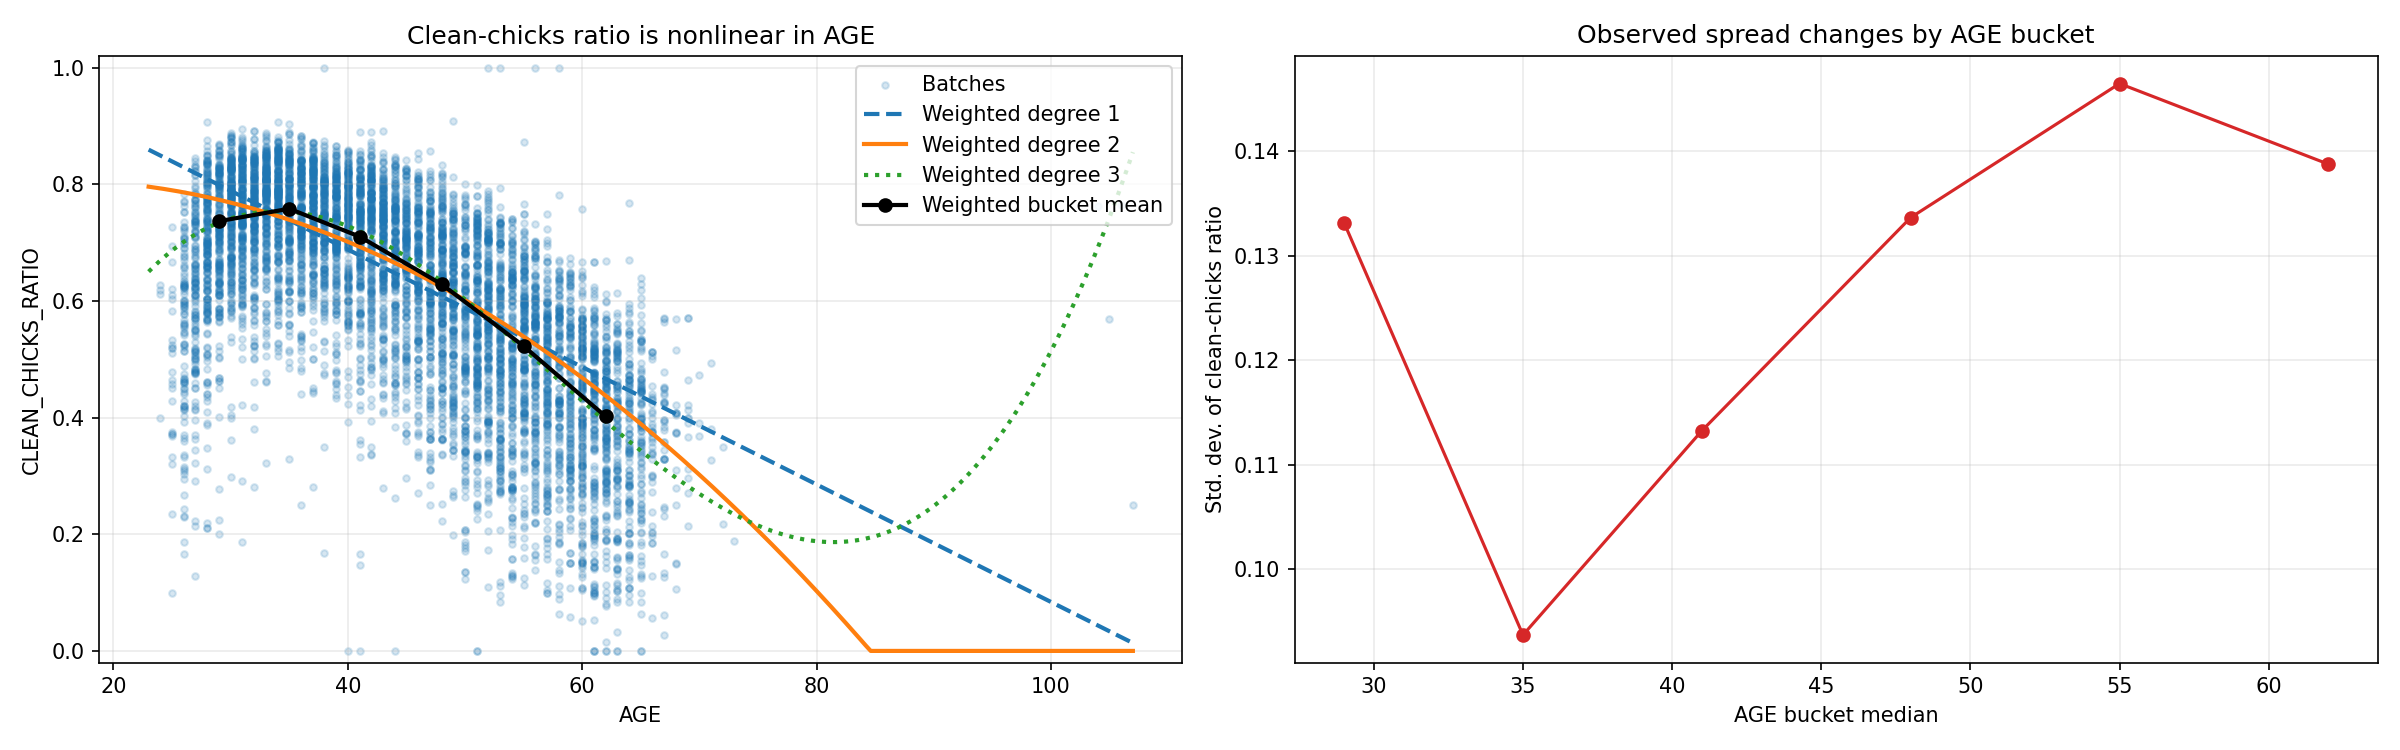

In [12]:
age_curve_summary, age_poly_comparison = age_curve_diagnostics(modeling_df)
plot_age_curve_diagnostics(modeling_df, age_curve_summary, OUTPUT_DIR)
age_curve_summary.to_csv(OUTPUT_DIR / "age_curve_summary.csv", index=False)
age_poly_comparison.to_csv(OUTPUT_DIR / "age_polynomial_comparison.csv", index=False)
display(age_curve_summary)
display(age_poly_comparison)
Image(filename=str(OUTPUT_DIR / 'age_curve_diagnostic.png'))

## 4. OLS fit for the final five-predictor specification

The OLS model uses a cubic basis for `AGE`, a linear effect for `S.P.`, and dummy variables for `LINE`, `FARM_SOURCE`, and `STRAIN`. Confidence intervals are reported with HC3 robust standard errors because heteroskedasticity is present.

In [13]:
full_models = fit_full_models(modeling_df)
ols_model = full_models['ols_model']
ols_table = full_models['ols_table']
ols_table.to_csv(OUTPUT_DIR / 'ols_coefficients.csv', index=False)
print('OLS training RMSE:', full_models['ols_train_rmse'])
print('OLS R-squared:', ols_model.rsquared)
print('OLS adjusted R-squared:', ols_model.rsquared_adj)
print('OLS AIC:', ols_model.aic)
display(ols_table.head(15))

OLS training RMSE: 0.10536143806022401
OLS R-squared: 0.6473124336184819
OLS adjusted R-squared: 0.647189631541051
OLS AIC: -119383.151502841


,term,estimate,robust_se_hc3,t_value_hc3,p_value_hc3,ci_95_low_hc3,ci_95_high_hc3
0,const,0.763343,2.115377e-03,360.854374,0.000000e+00,0.759197,0.767489
1,AGE_CENTERED,-0.012085,5.978311e-05,-202.143678,0.000000e+00,-0.012202,-0.011968
2,AGE_CENTERED_SQ,-0.000496,4.228501e-06,-117.248314,0.000000e+00,-0.000504,-0.000487
3,AGE_CENTERED_CU,0.000012,1.985521e-07,58.801330,0.000000e+00,0.000011,0.000012
4,S.P.,-0.008562,1.081059e-04,-79.200800,0.000000e+00,-0.008774,-0.008350
5,LINE_ML,-0.068469,8.665069e-04,-79.017496,0.000000e+00,-0.070168,-0.066771
6,FARM_SOURCE_GP11,0.003226,2.071474e-03,1.557449,1.193684e-01,-0.000834,0.007286
7,FARM_SOURCE_GP12,-0.027154,2.199740e-03,-12.344028,5.693537e-35,-0.031465,-0.022842
8,FARM_SOURCE_GP14,-0.027894,2.635074e-03,-10.585706,3.629341e-26,-0.033059,-0.022729
9,FARM_SOURCE_GP15,0.008613,2.154762e-03,3.997214,6.415639e-05,0.004390,0.012836


In [14]:
ols_sig = full_models["ols_table"].copy()
ols_sig["significant_at_0_05"] = ols_sig["p_value_hc3"] < 0.05
ols_sig["significance"] = ols_sig["p_value_hc3"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)
ols_sig.to_csv(OUTPUT_DIR / "ols_coefficients_with_significance.csv", index=False)
display(
    ols_sig[
        [
            "term",
            "estimate",
            "p_value_hc3",
            "ci_95_low_hc3",
            "ci_95_high_hc3",
            "significant_at_0_05",
            "significance",
        ]
    ]
)

,term,estimate,p_value_hc3,ci_95_low_hc3,ci_95_high_hc3,significant_at_0_05,significance
0,const,0.763343,0.000000e+00,0.759197,0.767489,True,***
1,AGE_CENTERED,-0.012085,0.000000e+00,-0.012202,-0.011968,True,***
2,AGE_CENTERED_SQ,-0.000496,0.000000e+00,-0.000504,-0.000487,True,***
3,AGE_CENTERED_CU,0.000012,0.000000e+00,0.000011,0.000012,True,***
4,S.P.,-0.008562,0.000000e+00,-0.008774,-0.008350,True,***
5,LINE_ML,-0.068469,0.000000e+00,-0.070168,-0.066771,True,***
6,FARM_SOURCE_GP11,0.003226,1.193684e-01,-0.000834,0.007286,False,ns
7,FARM_SOURCE_GP12,-0.027154,5.693537e-35,-0.031465,-0.022842,True,***
8,FARM_SOURCE_GP14,-0.027894,3.629341e-26,-0.033059,-0.022729,True,***
9,FARM_SOURCE_GP15,0.008613,6.415639e-05,0.004390,0.012836,True,***


## 5. Bayesian fits: weak prior and informative prior

The Bayesian implementation uses the same design matrix as OLS and a conjugate Normal-Inverse-Gamma formulation. The informative prior is empirical Bayes: its center comes from the standardized OLS fit, so it demonstrates prior shrinkage but should not be treated as external domain knowledge.

In [15]:
bayes_noninf = full_models['bayes_noninf']
bayes_inf = full_models['bayes_inf']

bayes_noninf['original_table'].to_csv(OUTPUT_DIR / 'bayesian_noninformative_coefficients.csv', index=False)
bayes_inf['original_table'].to_csv(OUTPUT_DIR / 'bayesian_informative_coefficients.csv', index=False)
prior_table = pd.DataFrame({
    'term': ['Intercept'] + list(full_models['X_full'].columns),
    'prior_mean_from_standardized_ols': full_models['prior_mean'],
    'prior_sd': full_models['prior_sd'],
})
prior_table.to_csv(OUTPUT_DIR / 'informative_prior_parameters.csv', index=False)
ppc = pd.concat([
    bayes_noninf['ppc'].assign(prior='noninformative'),
    bayes_inf['ppc'].assign(prior='informative'),
], ignore_index=True)
ppc.to_csv(OUTPUT_DIR / 'posterior_predictive_checks.csv', index=False)

print('Bayesian weak-prior RMSE:', bayes_noninf['rmse'])
print('Bayesian informative-prior RMSE:', bayes_inf['rmse'])
display(bayes_noninf['original_table'].head(15))
display(bayes_inf['original_table'].head(15))
display(ppc)

Bayesian weak-prior RMSE: 0.10536143806022401
Bayesian informative-prior RMSE: 0.10536143806022401


,term,posterior_mean,credible_95_low,credible_95_high
0,Intercept,0.763370,0.758885,0.767301
1,AGE_CENTERED,-0.012083,-0.012162,-0.012007
2,AGE_CENTERED_SQ,-0.000496,-0.000503,-0.000489
3,AGE_CENTERED_CU,0.000012,0.000012,0.000012
4,S.P.,-0.008560,-0.008761,-0.008363
5,LINE_ML,-0.068452,-0.070138,-0.066868
6,FARM_SOURCE_GP11,0.003205,-0.001371,0.007402
7,FARM_SOURCE_GP12,-0.027252,-0.031122,-0.022896
8,FARM_SOURCE_GP14,-0.027734,-0.033300,-0.021834
9,FARM_SOURCE_GP15,0.008487,0.004377,0.012638


,term,posterior_mean,credible_95_low,credible_95_high
0,Intercept,0.763290,0.759101,0.767322
1,AGE_CENTERED,-0.012084,-0.012166,-0.012003
2,AGE_CENTERED_SQ,-0.000496,-0.000503,-0.000489
3,AGE_CENTERED_CU,0.000012,0.000011,0.000012
4,S.P.,-0.008566,-0.008760,-0.008369
5,LINE_ML,-0.068472,-0.070017,-0.066750
6,FARM_SOURCE_GP11,0.003275,-0.000386,0.007075
7,FARM_SOURCE_GP12,-0.027082,-0.031259,-0.022848
8,FARM_SOURCE_GP14,-0.027719,-0.034021,-0.021172
9,FARM_SOURCE_GP15,0.008646,0.004050,0.013103


,actual_mean,predicted_mean,actual_sd,residual_sd,rmse,posterior_predictive_95_coverage,posterior_predictive_95_width_mean,prior
0,0.607314,0.607314,0.177415,0.105362,0.105361,0.94566,0.413091,noninformative
1,0.607314,0.607314,0.177415,0.105362,0.105361,0.94566,0.413091,informative


### 5a. Predicted vs actual — all three models

Each panel plots predicted hatch ratio against actual hatch ratio, colored by AGE bucket. The dashed diagonal is perfect prediction. The grey band represents the model's 95% prediction interval: classical OLS prediction intervals for the OLS panel and posterior predictive 95% intervals for the two Bayesian panels.

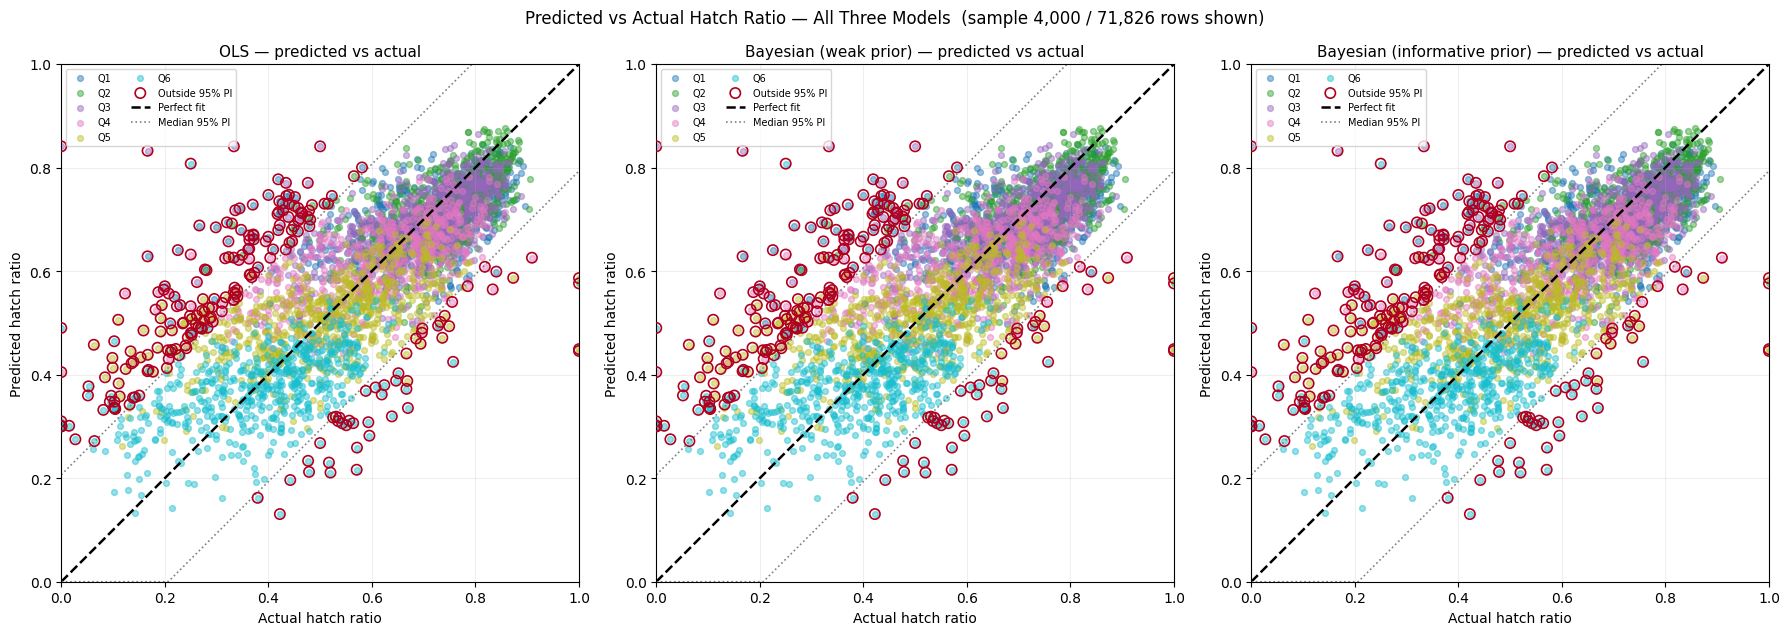

,model,n_rows,rmse,mae,bias,pi95_coverage
0,OLS,71826,0.105361,0.078546,-0.0,0.9457
1,Bayesian weak prior,71826,0.105361,0.078546,-0.0,0.9457
2,Bayesian inform. prior,71826,0.105361,0.078546,-0.0,0.9457


In [16]:
PLOT_N = 4000  # points to display per panel; coverage stats use all rows

def _pred_vs_actual_ax(ax, actual, predicted, age_bucket, eggset,
                        title, interval_low=None, interval_high=None,
                        rng_seed=RANDOM_STATE):
    idx = actual.sample(n=min(PLOT_N, len(actual)), random_state=rng_seed).index
    a_s, p_s, b_s = actual.loc[idx], predicted.loc[idx], age_bucket.loc[idx]

    palette = plt.cm.get_cmap("tab10")
    buckets = sorted(age_bucket.dropna().unique())
    colors = {b: palette(i / max(len(buckets) - 1, 1)) for i, b in enumerate(buckets)}

    for b in buckets:
        mask = b_s == b
        ax.scatter(a_s[mask], p_s[mask], s=18, alpha=0.45,
                   color=colors[b], label=str(b))

    if interval_low is not None and interval_high is not None:
        lo_s = interval_low.loc[idx]
        hi_s = interval_high.loc[idx]
        out_mask = ~a_s.between(lo_s, hi_s, inclusive="both")
        if out_mask.any():
            ax.scatter(a_s[out_mask], p_s[out_mask],
                       s=55, facecolors="none", edgecolors="#B00020",
                       linewidth=1.2, label="Outside 95% PI", zorder=5)

    vmin = float(min(actual.min(), predicted.min()))
    vmax = float(max(actual.max(), predicted.max()))
    pad = max((vmax - vmin) * 0.04, 0.01)
    lim = (max(0.0, vmin - pad), min(1.0, vmax + pad))
    line = np.linspace(*lim, 200)
    ax.plot(line, line, color="black", linestyle="--", linewidth=1.8, label="Perfect fit")

    if interval_low is not None and interval_high is not None:
        half = float(np.median((interval_high - interval_low) / 2))
        ax.plot(line, np.clip(line - half, 0, 1), color="gray", linestyle=":", linewidth=1.2)
        ax.plot(line, np.clip(line + half, 0, 1), color="gray", linestyle=":", linewidth=1.2,
                label="Median 95% PI")

    ax.set_xlim(*lim); ax.set_ylim(*lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Actual hatch ratio"); ax.set_ylabel("Predicted hatch ratio")
    ax.grid(True, alpha=0.20)
    ax.legend(fontsize=7, loc="upper left", ncol=2)


actual     = modeling_df[TARGET_RATIO_COL]
eggset     = modeling_df[DENOM_COL]
age_bucket = modeling_df["AGE_BUCKET"]
ols_pred   = pd.Series(full_models["ols_fitted"], index=modeling_df.index)

# Classical OLS 95% prediction intervals
X_full_sm = sm.add_constant(full_models["X_full"], has_constant="add")
ols_pred_frame = full_models["ols_model"].get_prediction(X_full_sm).summary_frame(alpha=0.05)
ols_lo = pd.Series(ols_pred_frame["obs_ci_lower"].clip(0, 1), index=modeling_df.index)
ols_hi = pd.Series(ols_pred_frame["obs_ci_upper"].clip(0, 1), index=modeling_df.index)


def _bayes_pi(fit):
    df_t = 2 * fit["an"]
    tcrit = stats.t.ppf(0.975, df=df_t)
    x_v_x = np.einsum("ij,jk,ik->i", fit["X_design"], fit["Vn"], fit["X_design"])
    pred_scale = np.sqrt((fit["bn"] / fit["an"]) * (1 + x_v_x))
    lo = pd.Series(np.clip(fit["fitted"] - tcrit * pred_scale, 0, 1), index=modeling_df.index)
    hi = pd.Series(np.clip(fit["fitted"] + tcrit * pred_scale, 0, 1), index=modeling_df.index)
    return lo, hi


noninf_pred          = pd.Series(full_models["bayes_noninf"]["fitted"], index=modeling_df.index)
noninf_lo, noninf_hi = _bayes_pi(full_models["bayes_noninf"])

inf_pred          = pd.Series(full_models["bayes_inf"]["fitted"], index=modeling_df.index)
inf_lo, inf_hi    = _bayes_pi(full_models["bayes_inf"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
_pred_vs_actual_ax(
    axes[0], actual, ols_pred, age_bucket, eggset,
    "OLS — predicted vs actual",
    interval_low=ols_lo, interval_high=ols_hi
)
_pred_vs_actual_ax(
    axes[1], actual, noninf_pred, age_bucket, eggset,
    "Bayesian (weak prior) — predicted vs actual",
    interval_low=noninf_lo, interval_high=noninf_hi
)
_pred_vs_actual_ax(
    axes[2], actual, inf_pred, age_bucket, eggset,
    "Bayesian (informative prior) — predicted vs actual",
    interval_low=inf_lo, interval_high=inf_hi
)

plt.suptitle(f"Predicted vs Actual Hatch Ratio — All Three Models  (sample {PLOT_N:,} / {len(actual):,} rows shown)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

# Coverage computed on ALL rows
summaries = []
for label, pred, lo, hi in [
    ("OLS",                    ols_pred,    ols_lo,     ols_hi),
    ("Bayesian weak prior",    noninf_pred, noninf_lo,  noninf_hi),
    ("Bayesian inform. prior", inf_pred,    inf_lo,     inf_hi),
]:
    row = {
        "model":  label,
        "n_rows": len(actual),
        "rmse":   round(float(rmse(actual, pred)), 6),
        "mae":    round(float((pred - actual).abs().mean()), 6),
        "bias":   round(float((pred - actual).mean()), 6),
        "pi95_coverage": round(float(actual.between(lo, hi, inclusive="both").mean()), 4),
    }
    summaries.append(row)

pred_vs_actual_summary = pd.DataFrame(summaries)
pred_vs_actual_summary.to_csv(OUTPUT_DIR / "predicted_vs_actual_summary.csv", index=False)
display(pred_vs_actual_summary)

## 6. Model complexity: CV, bootstrap, AIC, and WAIC

This cell reuses saved outputs when they already exist. Otherwise it recomputes the complexity tables.

In [17]:
ols_path = OUTPUT_DIR / 'ols_model_complexity.csv'
bayes_path = OUTPUT_DIR / 'bayesian_model_complexity.csv'
if ols_path.exists() and bayes_path.exists():
    ols_complexity = pd.read_csv(ols_path)
    bayes_complexity = pd.read_csv(bayes_path)
else:
    ols_complexity, bayes_complexity = run_complexity_analysis(modeling_df)

ols_complexity.to_csv(OUTPUT_DIR / 'ols_model_complexity.csv', index=False)
bayes_complexity.to_csv(OUTPUT_DIR / 'bayesian_model_complexity.csv', index=False)
plot_complexity_curves(ols_complexity, bayes_complexity, OUTPUT_DIR)

best_ols_cv = ols_complexity.loc[ols_complexity['cv_rmse_mean'].idxmin()]
best_ols_boot = ols_complexity.loc[ols_complexity['bootstrap_632_rmse'].idxmin()]
best_ols_aic = ols_complexity.loc[ols_complexity['aic'].idxmin()]
best_bayes_cv = bayes_complexity.loc[bayes_complexity['bayes_cv_rmse_mean'].idxmin()]
best_bayes_waic = bayes_complexity.loc[bayes_complexity['waic'].idxmin()]
selection_summary = pd.DataFrame([
    {'criterion': 'OLS 5-fold CV RMSE', 'best_k': int(best_ols_cv['k']), 'selected_model': best_ols_cv['conceptual_predictors'], 'score': float(best_ols_cv['cv_rmse_mean'])},
    {'criterion': 'OLS 0.632 bootstrap RMSE', 'best_k': int(best_ols_boot['k']), 'selected_model': best_ols_boot['conceptual_predictors'], 'score': float(best_ols_boot['bootstrap_632_rmse'])},
    {'criterion': 'OLS AIC', 'best_k': int(best_ols_aic['k']), 'selected_model': best_ols_aic['conceptual_predictors'], 'score': float(best_ols_aic['aic'])},
    {'criterion': 'Bayesian 5-fold CV RMSE', 'best_k': int(best_bayes_cv['k']), 'selected_model': best_bayes_cv['conceptual_predictors'], 'score': float(best_bayes_cv['bayes_cv_rmse_mean'])},
    {'criterion': 'Bayesian WAIC', 'best_k': int(best_bayes_waic['k']), 'selected_model': best_bayes_waic['conceptual_predictors'], 'score': float(best_bayes_waic['waic'])},
])
selection_summary.to_csv(OUTPUT_DIR / 'model_selection_summary.csv', index=False)

display(ols_complexity)
display(bayes_complexity)

,k,conceptual_predictors,design_columns,cv_rmse_mean,cv_rmse_sd,train_rmse,bootstrap_632_rmse,bootstrap_oob_rmse,aic,bic,r2,adj_r2
0,1,AGE (cubic basis),3,0.124980,0.001144,0.124962,0.125063,0.125122,-94918.000202,-94881.272195,0.503883,0.503862
1,2,AGE + S.P.,4,0.120570,0.001040,0.120548,0.120469,0.120423,-100082.549554,-100036.639545,0.538316,0.538290
2,3,AGE + S.P. + LINE,5,0.115407,0.001067,0.115381,0.115454,0.115496,-106373.709591,-106318.617580,0.577046,0.577016
3,4,AGE + S.P. + LINE + FARM_SOURCE,23,0.109406,0.001194,0.109353,0.109257,0.109201,-114045.706729,-113825.338686,0.620084,0.619963
4,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,25,0.105423,0.001149,0.105361,0.105521,0.105613,-119383.151503,-119144.419456,0.647312,0.647190


,k,conceptual_predictors,design_columns,bayes_cv_rmse_mean,bayes_cv_rmse_sd,bayes_train_rmse,waic,lppd,p_waic
0,1,AGE (cubic basis),3,0.124980,0.001144,0.124962,-94911.046771,47465.355175,9.831790
1,2,AGE + S.P.,4,0.120570,0.001040,0.120548,-100075.170860,50048.716816,11.131386
2,3,AGE + S.P. + LINE,5,0.115407,0.001067,0.115381,-106364.631876,53196.093351,13.777413
3,4,AGE + S.P. + LINE + FARM_SOURCE,23,0.109406,0.001194,0.109353,-114034.211642,57050.599472,33.493651
4,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,25,0.105423,0.001149,0.105361,-119369.677246,59722.539673,37.701050


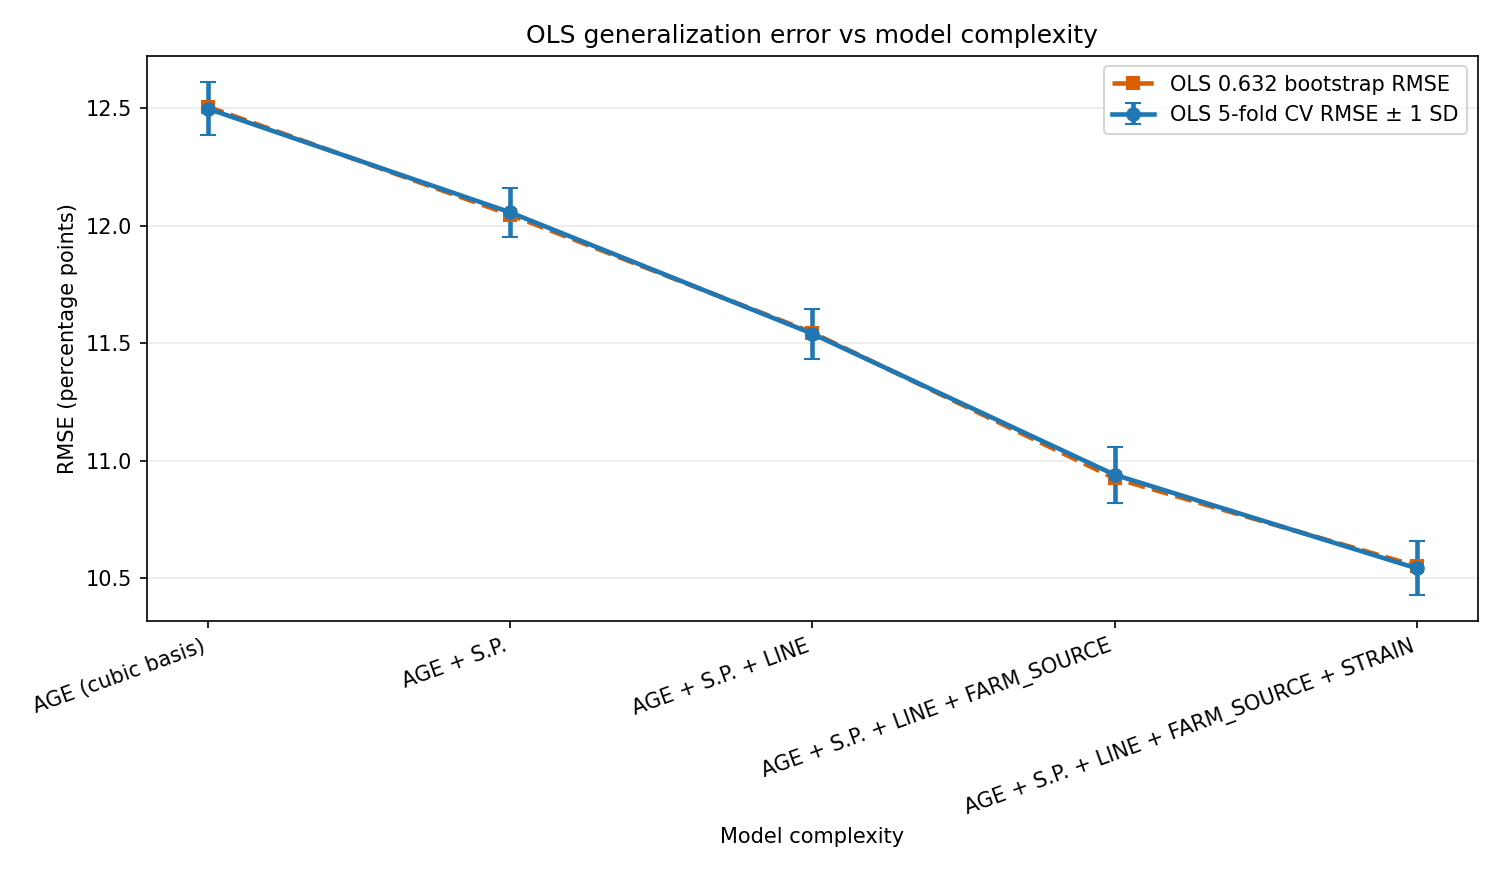

In [18]:
Image(filename=str(OUTPUT_DIR / 'ols_model_complexity.png'))

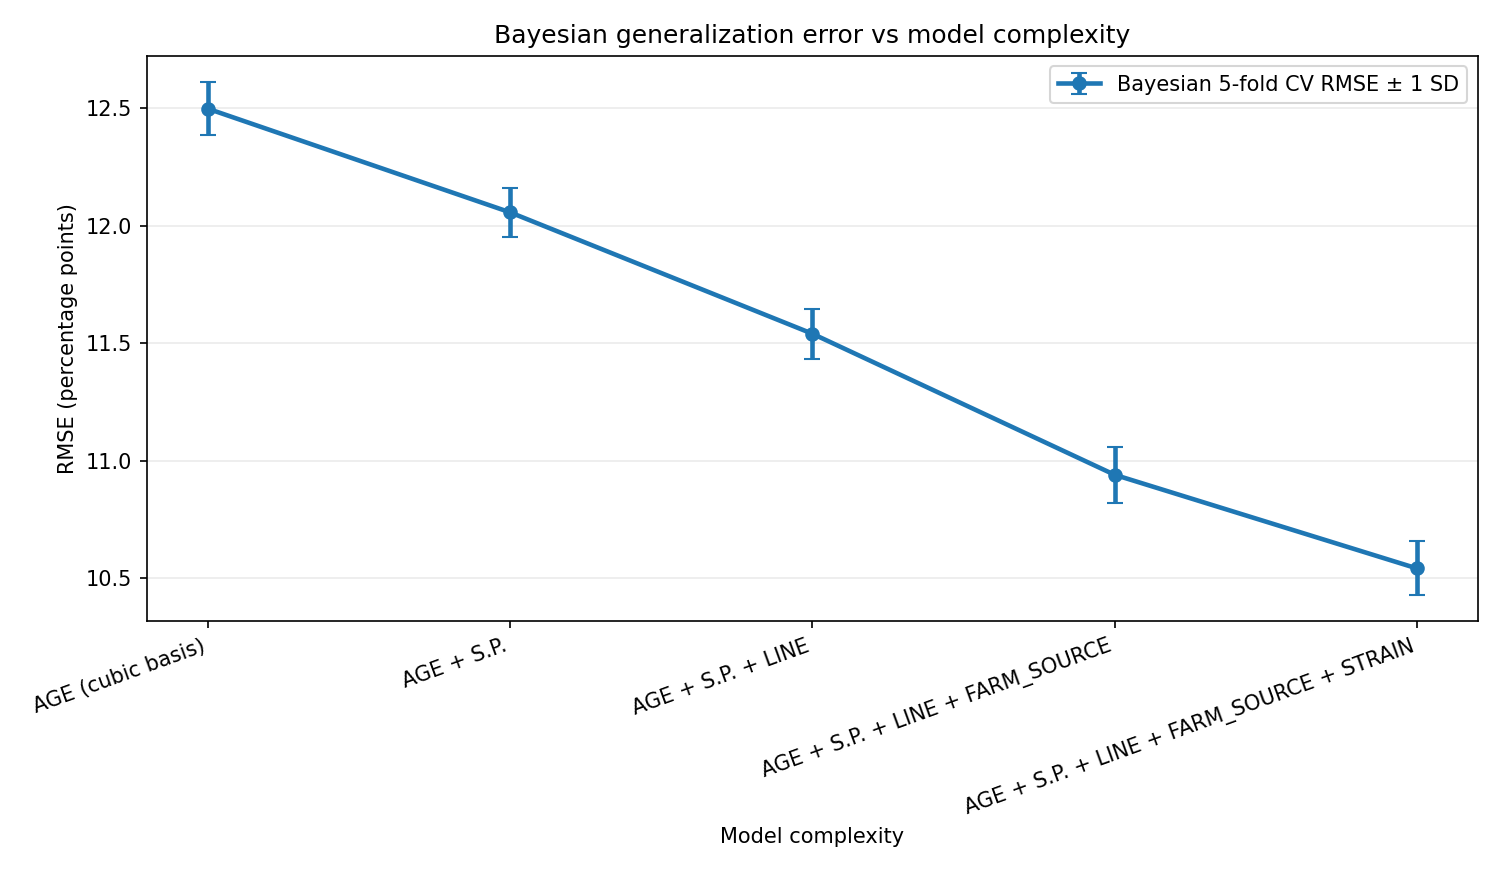

In [19]:
Image(filename=str(OUTPUT_DIR / 'bayesian_model_complexity.png'))

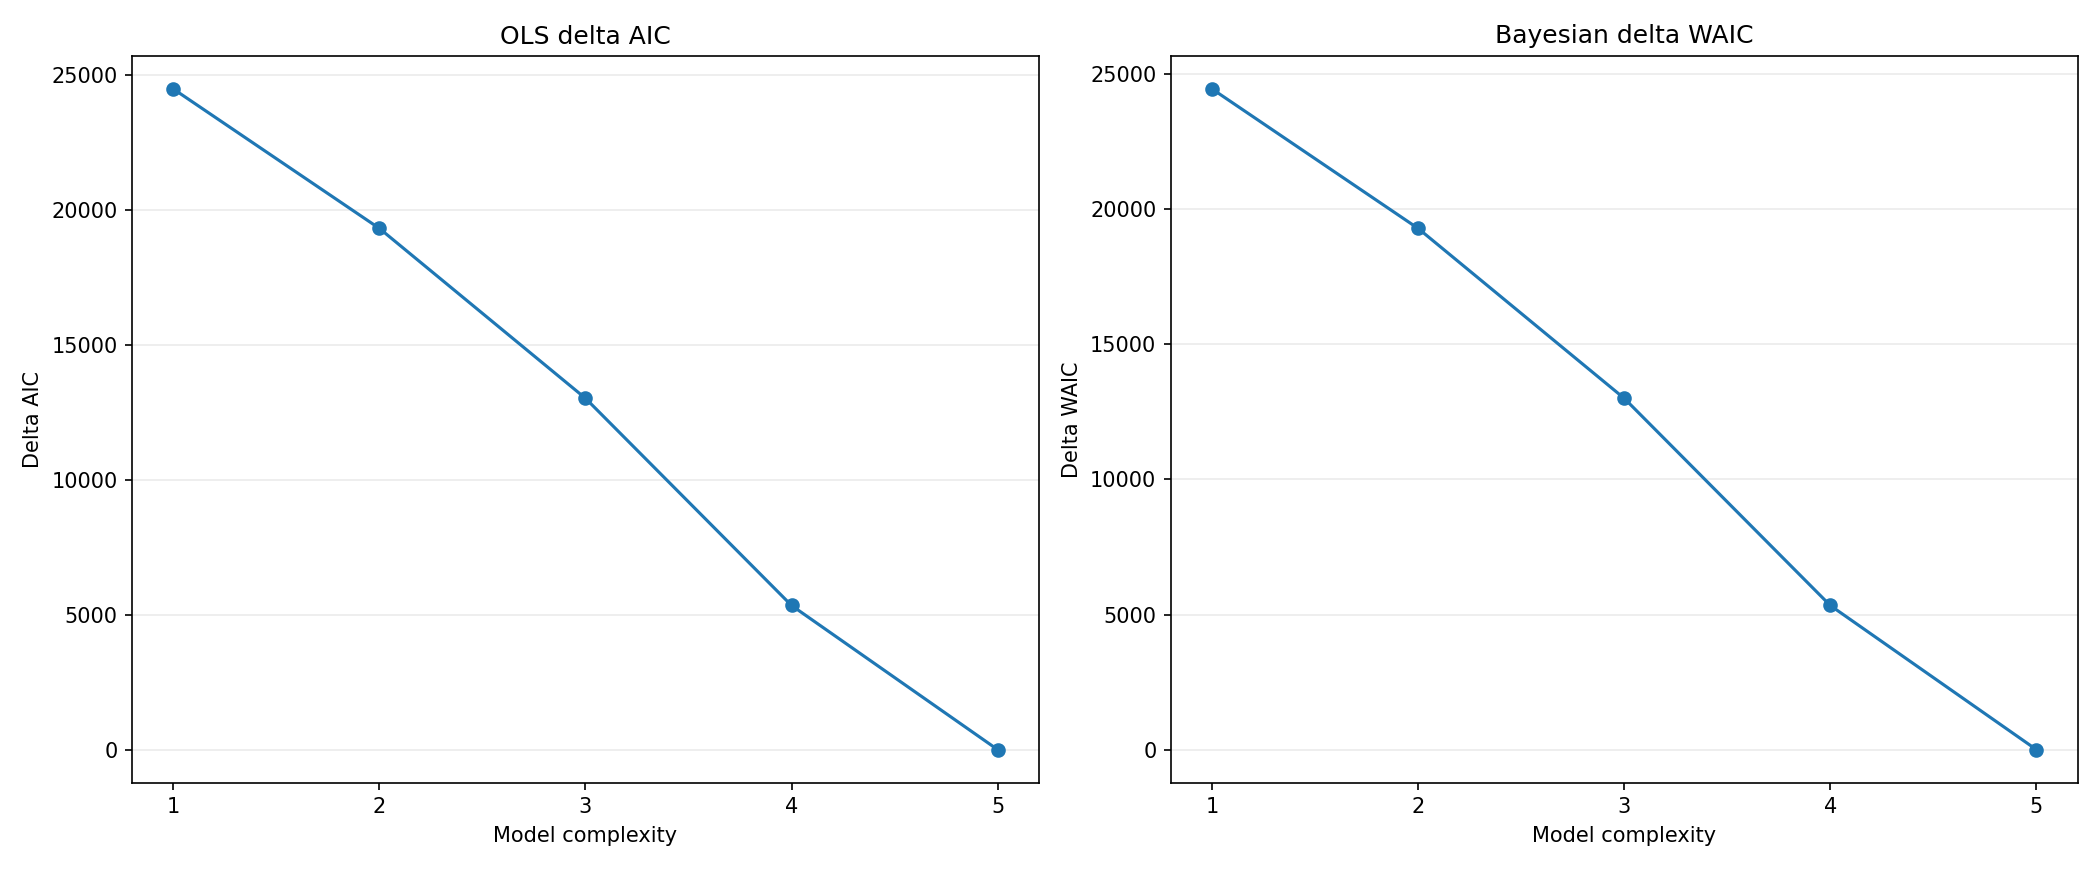

In [20]:
Image(filename=str(OUTPUT_DIR / 'information_criteria_by_complexity.png'))

## 7. Residual diagnostics and final selection

The residual plots check whether the cubic AGE benchmark leaves systematic structure behind. The final selection table aggregates the five requested criteria.

,test,lm_statistic,lm_pvalue,f_statistic,f_pvalue
0,Breusch-Pagan heteroskedasticity,3321.685148,0.0,139.259545,0.0


,design,term,vif
0,raw_age_polynomial,AGE,470.527903
1,raw_age_polynomial,AGE_RAW_SQ,1493.358611
2,raw_age_polynomial,AGE_RAW_CU,322.154074
3,raw_age_polynomial,S.P.,1.016114
4,centered_age_polynomial,AGE_CENTERED,1.388700
5,centered_age_polynomial,AGE_CENTERED_SQ,2.238875
6,centered_age_polynomial,AGE_CENTERED_CU,2.722019
7,centered_age_polynomial,S.P.,1.016114


,AGE_BUCKET,rows,mean_residual,residual_std,abs_residual_p90,weighted_ratio_mae
0,Q1,12319.0,-0.002123,0.108803,0.163705,0.067661
1,Q2,12395.0,0.016358,0.076911,0.118936,0.056185
2,Q3,11637.0,-0.002629,0.092313,0.130555,0.059968
3,Q4,13034.0,-0.009130,0.103165,0.168515,0.072772
4,Q5,11957.0,-0.013125,0.117785,0.195077,0.086465
5,Q6,10484.0,0.012393,0.125936,0.206482,0.087045


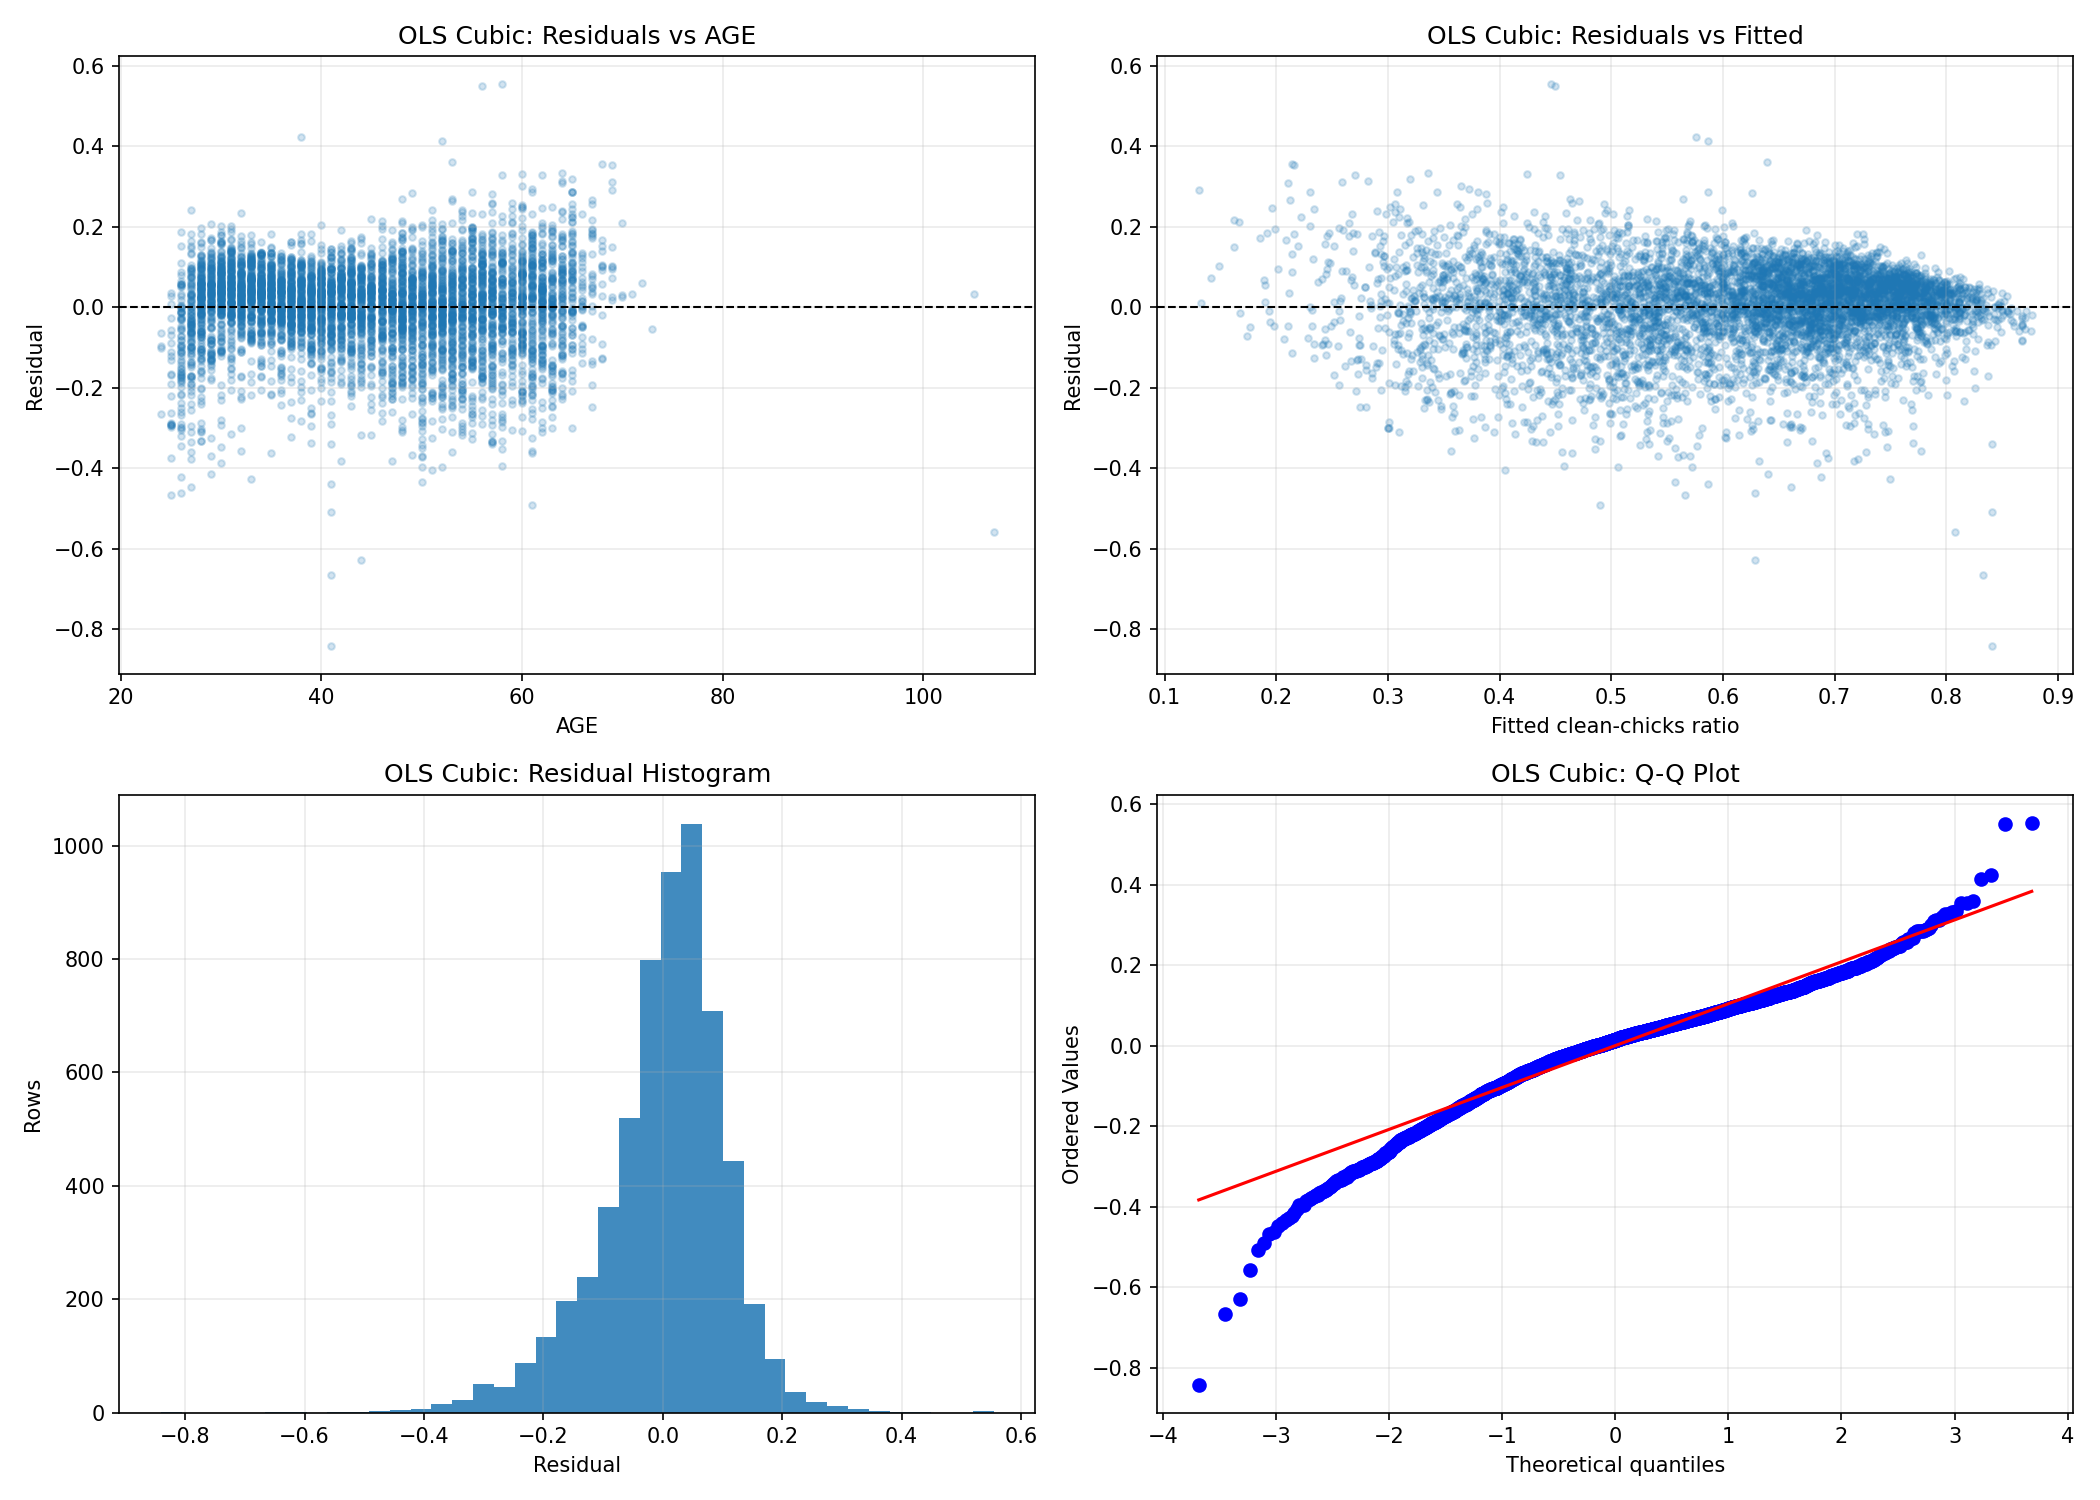

In [21]:
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(
    full_models['ols_model'].resid,
    full_models['ols_model'].model.exog,
)
assumption_tests = pd.DataFrame([
    {
        'test': 'Breusch-Pagan heteroskedasticity',
        'lm_statistic': float(bp_lm),
        'lm_pvalue': float(bp_lm_pvalue),
        'f_statistic': float(bp_fvalue),
        'f_pvalue': float(bp_f_pvalue),
    }
])
assumption_tests.to_csv(OUTPUT_DIR / 'ols_assumption_tests.csv', index=False)

vif_table = compute_vif_table(modeling_df, full_models['metadata'].age_center)
vif_table.to_csv(OUTPUT_DIR / 'ols_vif_table.csv', index=False)

residual_by_age = summarize_residuals_by_age(modeling_df, full_models['ols_fitted'])
residual_by_age.to_csv(OUTPUT_DIR / 'ols_residuals_by_age_bucket.csv', index=False)
plot_residual_diagnostics(modeling_df, full_models['ols_fitted'], OUTPUT_DIR)

display(assumption_tests)
display(vif_table)
display(residual_by_age)
Image(filename=str(OUTPUT_DIR / 'ols_cubic_residual_diagnostics.png'))

In [22]:
if 'selection_summary' not in globals():
    selection_summary = pd.read_csv(OUTPUT_DIR / 'model_selection_summary.csv')
display(selection_summary)
print('Recommended final conceptual model: AGE + S.P. + LINE + FARM_SOURCE + STRAIN, with AGE represented by a cubic basis.')

,criterion,best_k,selected_model,score
0,OLS 5-fold CV RMSE,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,0.105423
1,OLS 0.632 bootstrap RMSE,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,0.105521
2,OLS AIC,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,-119383.151503
3,Bayesian 5-fold CV RMSE,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,0.105423
4,Bayesian WAIC,5,AGE + S.P. + LINE + FARM_SOURCE + STRAIN,-119369.677246


Recommended final conceptual model: AGE + S.P. + LINE + FARM_SOURCE + STRAIN, with AGE represented by a cubic basis.


## 8. Saved outputs

The refined report uses the files in `Bayesian_non_Bayesian/hatch_outputs_refined/`, including coefficient tables, posterior predictive checks, model-complexity tables, and the diagnostic plots.